# 분류

In [110]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd, numpy as np

fish = pd.read_csv('https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv')

# 입력(무게·길이·대각선·높이·너비), 타깃(종)
fish_input  = fish[['Weight','Length','Diagonal','Height','Width']].to_numpy()
fish_target = fish['Species'].to_numpy()


In [111]:

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

ss = StandardScaler()
train_scaled = ss.fit_transform(train_input)
test_scaled  = ss.transform(test_input)

kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.predict_proba(test_scaled[:5]))

[[0.         0.         1.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         1.
  0.        ]
 [0.         0.         0.         1.         0.         0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]]


In [112]:
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


C:\Users\pipa03\AppData\Local\Temp\ipykernel_11744\1820139643.py:56: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\pipa03\p1-data\c2-machine-learning\ml01\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


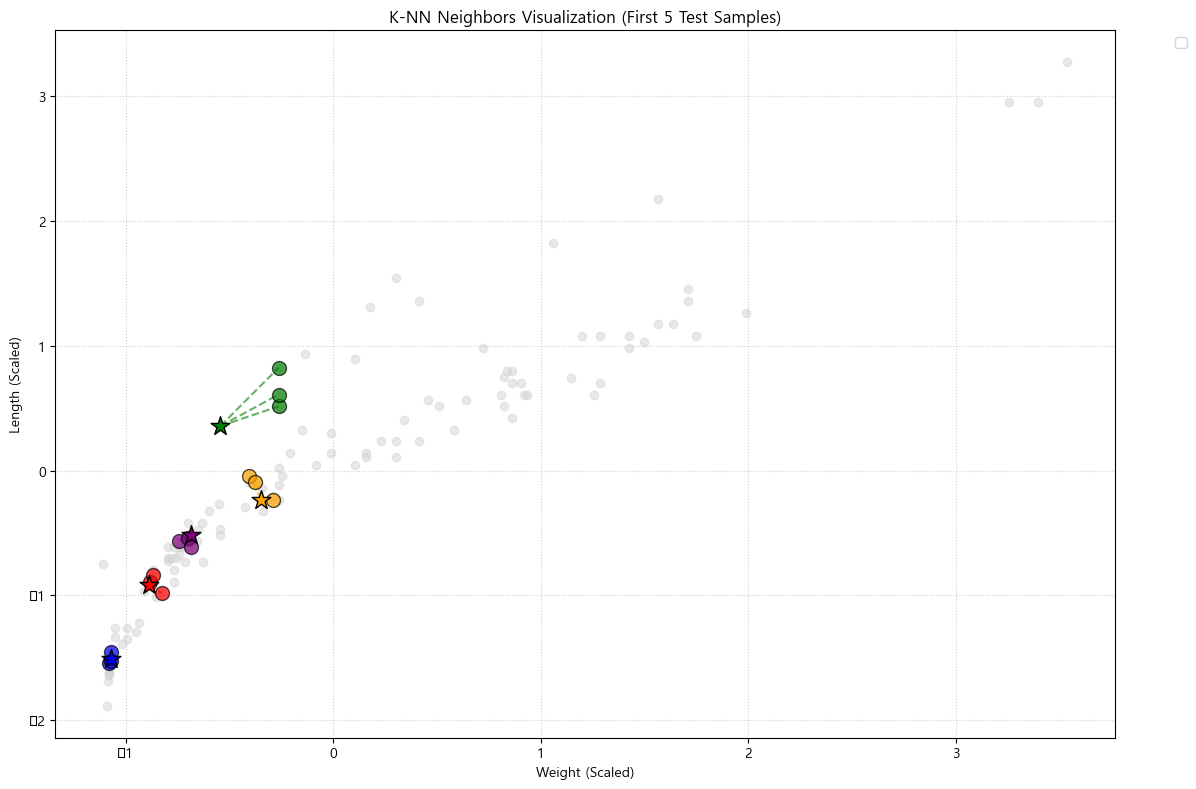

In [113]:
import matplotlib.pyplot as plt

# 1. 시각화를 위해 2차원 특성(Weight, Length)의 인덱스 추출
# scaled 데이터에서 Weight는 index 0, Length는 index 1 입니다.
feat_x = 0  # Weight
feat_y = 1  # Length

# 2. test_scaled[:5] 샘플들의 이웃 정보 가져오기
# kneighbors() 메서드는 각 샘플에서 가장 가까운 이웃까지의 (거리, 인덱스)를 반환합니다.
distances, indexes = kn.kneighbors(test_scaled[:5])

# 3. 시각화 그래프 그릴 준비
plt.figure(figsize=(12, 8))

# 전체 훈련 데이터 산점도 (배경)
plt.scatter(train_scaled[:, feat_x], train_scaled[:, feat_y], 
            c='lightgray', alpha=0.5, label='All Train Data')

# 테스트 샘플별로 색상을 다르게 하여 이웃 관계 시각화
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(5):
    # 현재 테스트 샘플 위치
    test_sample = test_scaled[i]
    
    # 현재 테스트 샘플의 이웃들 위치 (훈련 데이터 중에서 찾음)
    neighbors = train_scaled[indexes[i]]
    
    # 테스트 샘플 표시 (별 모양)
    plt.scatter(test_sample[feat_x], test_sample[feat_y], 
                color=colors[i], marker='*', s=200, edgecolor='black', 
                zorder=5, label=f'Test Sample {i+1} ({kn.predict(test_scaled[[i]])[0]})')
    
    # 이웃 샘플 표시 (테스트 샘플과 같은 색상의 큰 원)
    plt.scatter(neighbors[:, feat_x], neighbors[:, feat_y], 
                color=colors[i], marker='o', s=100, edgecolor='black', alpha=0.7,
                zorder=4, label=f'Neighbors of Sample {i+1}')
    
    # 테스트 샘플과 이웃들 사이에 선 연결하기
    for neighbor in neighbors:
        plt.plot([test_sample[feat_x], neighbor[feat_x]], 
                 [test_sample[feat_y], neighbor[feat_y]], 
                 color=colors[i], linestyle='--', alpha=0.6)

# 그래프 스타일링
plt.xlabel('Weight (Scaled)')
plt.ylabel('Length (Scaled)')
plt.title('K-NN Neighbors Visualization (First 5 Test Samples)')

# 범례가 너무 중복되므로 유니크한 것만 선별해서 표시
handles, labels = plt.gca().get_images(), plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

---

# 로지스틱 회귀 - 분류

In [114]:
from sklearn.linear_model import LogisticRegression

# 도미와 빙어만 추출해준다.
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt' )
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

In [115]:
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)
print(lr.classes_)   # 클래스는 2개
print(lr.coef_)      # 특성 5개의 가중치 w
print(lr.intercept_) # 절편 b

['Bream' 'Smelt']
[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]]
[-2.16172774]


In [116]:
# 결정 함수 f(w,b) -> z 함수
decisions = lr.decision_function(train_bream_smelt[:5])  # 샘플 5개만
print(decisions)

[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [117]:
from scipy.special import expit
# z를 시그모이드 함수애 통과
print(expit(decisions))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


c:\Users\pipa03\p1-data\c2-machine-learning\ml01\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


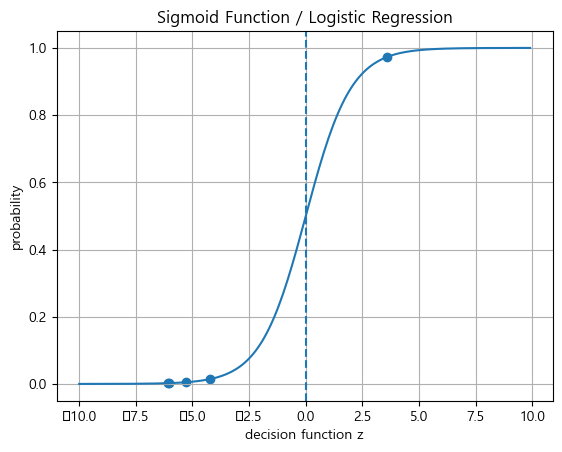

In [118]:
# AI 시각화 : 결정 경계, 시그모이드 함수 시각화

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

# x축: 결정 함수 값
z = np.arange(-10, 10, 0.1)

# 시그모이드 함수 시각화
plt.plot(z, expit(z))

# 결정 경계선
plt.axvline(0, linestyle='--')

# 실제 샘플 5개의 결정값 표시
plt.scatter(decisions, expit(decisions))

plt.xlabel('decision function z')
plt.ylabel('probability')
plt.title('Sigmoid Function / Logistic Regression')
plt.grid()
plt.show()

# 다중 분류
- softmax 함수
  - e (자연 로그의 밑) 지수 함수를 함수에 적용
  - 정규화 -> 모든 확률의 합은 100% 되게끔. 하지만 가장 큰 점수를 극대화시키는 함수

In [119]:
# 전체 7종 분류
lr = LogisticRegression(C=20, max_iter=1000)
# C (규제의 역수) 값은 클수록 규제가 약하고 자유도가 높음
# max_iter는 한 번에 결정 경계를 못 찾기 때문에 반복 학습 과정을 거침 (경사하강법) 최대 몇 번 할 것인가
lr.fit(train_scaled, train_target)

print(lr.classes_)
# ['Bream' 'Parkki' 'Perch' 'Pike'
#  'Roach' 'Smelt' 'Whitefish']

proba = lr.predict_proba(test_scaled[:3])
print(proba.round(3))
# train: 0.9328  test: 0.9250

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]]


In [120]:
# z f(w,b)
decision = lr.decision_function(test_scaled[:5])
print(decision.shape)

(5, 7)


In [121]:
# g(z)
from scipy.special import softmax
proba_from_softmax = softmax(decision, axis=1)
proba_from_softmax.round(3) # 결과가 로지스틱 회귀의 결과와 같다
# 다항 분류의 경우 softmax를 사용한다.

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])

In [122]:
proba_df = pd.DataFrame(
    lr.predict_proba(test_scaled[:5]).round(3),
    columns=lr.classes_
)
proba_df


,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
0,0.000,0.014,0.842,0.000,0.135,0.007,0.003
1,0.000,0.003,0.044,0.000,0.007,0.946,0.000
2,0.000,0.000,0.034,0.934,0.015,0.016,0.000
3,0.011,0.034,0.305,0.006,0.567,0.000,0.076
4,0.000,0.000,0.904,0.002,0.089,0.002,0.001


In [123]:
# 퍙가
lr.score(test_scaled, test_target) # 정확도. 92.5%

0.925

---
## 평가 지표
(Confusion Matrix)

In [124]:
from sklearn.metrics import confusion_matrix

y_true = [1, 0, 1, 1, 0, 1, 0, 0]  # 실제 정답
y_pred = [1, 0, 0, 1, 0, 1, 1, 0]  # 예측값

confusion_matrix(y_true, y_pred)
# TN=3, FP=1, FN=1, TP=3

array([[3, 1],
       [1, 3]])

In [125]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))       

              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8



## 타이타닉 데이터로 평가 지표 확인

In [126]:
import seaborn as sns
titanic = sns.load_dataset('titanic')

In [127]:
import seaborn as sns
titanic = sns.load_dataset('titanic')

# 기본 전처리
titanic_clean = titanic[['survived','pclass','sex','age','sibsp','parch','fare']].dropna()

In [128]:

# 인코딩
titanic_clean = pd.get_dummies(titanic_clean, columns=['sex'], drop_first=True)

titanic_clean.head(2)

,survived,pclass,age,sibsp,parch,fare,sex_male
0,0,3,22.0,1,0,7.2500,True
1,1,1,38.0,1,0,71.2833,False


In [129]:

X = titanic_clean.drop('survived', axis=1).values   # X : 6개 특성
y = titanic_clean['survived'].values    # y = 생존여부

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y)  # stratify로 불균형 비율 유지

ss = StandardScaler()
X_train_s = ss.fit_transform(X_train)
X_test_s  = ss.transform(X_test)

print("생존:", y.sum(), "사망:", len(y) - y.sum())
print("생존 비율:", y.mean().round(3))

생존: 290 사망: 424
생존 비율: 0.406


In [130]:
# 학습
lr = LogisticRegression()
lr.fit(X_train_s, y_train)    # 학습
y_pred = lr.predict(X_test_s) # 예측
lr.score(X_test_s, y_test)    # 평가

0.7932960893854749

In [131]:
print(confusion_matrix(y_test, y_pred))      # 혼동행렬
print(classification_report(y_test, y_pred)) # 평가지표

[[87 19]
 [18 55]]
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       106
           1       0.74      0.75      0.75        73

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



In [132]:
# ROC AUC 점수
from sklearn.metrics import roc_auc_score
y_score = lr.predict_proba(X_test_s)[:, 1] # 생존확률만 확인, 차원축소
print(y_score[:3])
roc_auc_score(y_test, y_score)  # AUC score : 0.86 => 준수한 성능

[0.08897927 0.20280058 0.09118474]


0.8634660118893771

In [133]:
# 임계값 조정해보기
y_score_30 = (y_score >= 0.3).astype(int)
print(classification_report(y_test, y_score_30, target_names=['사망', '생존']))

# 임계값을 0.3으로 낮췄을 때 (생존 기준)으로 리콜(재현율)이 오르고 정밀도 낮아짐.

              precision    recall  f1-score   support

          사망       0.85      0.69      0.76       106
          생존       0.65      0.82      0.72        73

    accuracy                           0.74       179
   macro avg       0.75      0.76      0.74       179
weighted avg       0.77      0.74      0.75       179



## SGD 확률적 경사하강법

In [107]:
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', random_state=42)  
# SGD에서는 손실함수를 어떤 것으로 할지 선택해야 한다.
# 손실함수를 log_loss 선정함으로 내부적으로 로지스틱 회귀 사용한다.

train_score, test_score = [], []
classes = np.unique(train_target)

for _ in range(300):
    sc.partial_fit(train_scaled, train_target,
                   classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

In [108]:
train_score

[0.5294117647058824,
 0.6218487394957983,
 0.6386554621848739,
 0.7142857142857143,
 0.7142857142857143,
 0.7394957983193278,
 0.7058823529411765,
 0.7226890756302521,
 0.7563025210084033,
 0.8067226890756303,
 0.8151260504201681,
 0.8487394957983193,
 0.8403361344537815,
 0.8571428571428571,
 0.8739495798319328,
 0.8571428571428571,
 0.8571428571428571,
 0.8739495798319328,
 0.8739495798319328,
 0.8739495798319328,
 0.8907563025210085,
 0.8739495798319328,
 0.8739495798319328,
 0.8823529411764706,
 0.8907563025210085,
 0.8907563025210085,
 0.8739495798319328,
 0.8991596638655462,
 0.8991596638655462,
 0.8991596638655462,
 0.8991596638655462,
 0.8907563025210085,
 0.8907563025210085,
 0.8823529411764706,
 0.907563025210084,
 0.8991596638655462,
 0.9243697478991597,
 0.907563025210084,
 0.9243697478991597,
 0.9159663865546218,
 0.9159663865546218,
 0.9243697478991597,
 0.9327731092436975,
 0.9243697478991597,
 0.9327731092436975,
 0.9243697478991597,
 0.9327731092436975,
 0.932773109243

In [109]:
test_score

[0.65,
 0.55,
 0.575,
 0.7,
 0.7,
 0.7,
 0.725,
 0.7,
 0.775,
 0.8,
 0.825,
 0.875,
 0.875,
 0.9,
 0.875,
 0.875,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.925,
 0.9,
 0.925,
 0.925,
 0.925,
 0.925,
 0.9,
 0.925,
 0.9,
 0.925,
 0.9,
 0.925,
 0.9,
 0.925,
 0.9,
 0.925,
 0.9,
 0.925,
 0.9,
 0.925,
 0.9,
 0.925,
 0.9,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.925,
 0.9

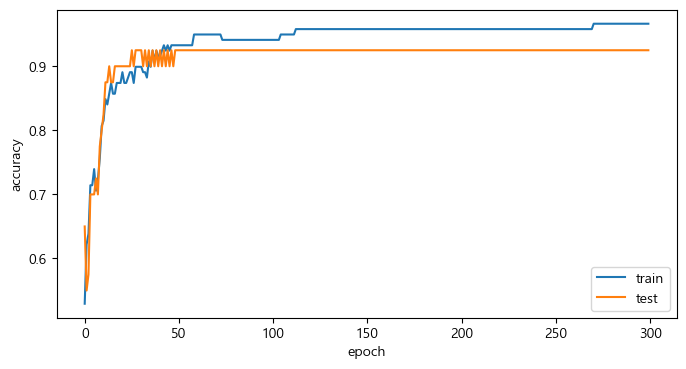

In [136]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(train_score, label='train')
plt.plot(test_score,  label='test')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

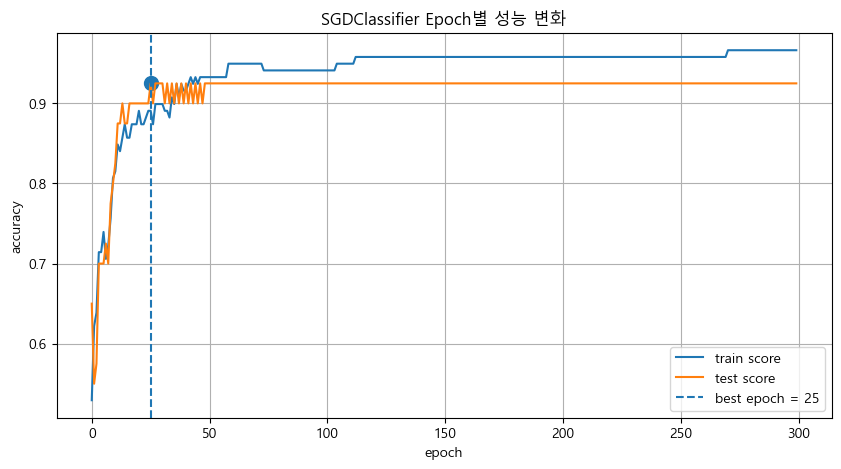

최적 epoch: 25
최고 test score: 0.9250


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

best_epoch = np.argmax(test_score)
best_score = test_score[best_epoch]

plt.figure(figsize=(10, 5))

plt.plot(train_score, label='train score')
plt.plot(test_score, label='test score')

plt.axvline(best_epoch, linestyle='--',
            label=f'best epoch = {best_epoch}')

plt.scatter(best_epoch, best_score, s=100)

plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('SGDClassifier Epoch별 성능 변화')

plt.legend()
plt.grid()

plt.show()

print(f'최적 epoch: {best_epoch}')
print(f'최고 test score: {best_score:.4f}')